# Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import utils.stats as sts
import utils.plotting as plotting

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "font.family": "Lato",
    "ytick.direction": "in",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
    })

## Teste - Período Rotacional

$$v\sin(i) = \dfrac{2\pi R \sin(i)}{P} \Rightarrow i = \arcsin\left[\dfrac{(v\sin(i))P}{2\pi R}\right]$$

In [2]:
def calcular_inclinacao(row, rotation_col):
    vsini = row["vsini"]                 # km/s
    rotp = row[rotation_col]             # dias
    radius = row["radius_val"] * 6.96e5  # Converter raio solar para km
    
    # Converter período de dias para segundos
    P = rotp * 24 * 3600                # segundos
    
    # Calcular sin(i)
    sin_i = (vsini * P) / (2 * np.pi * radius)
    
    # Garantir que sin(i) está no intervalo válido [-1, 1]
    sin_i = min(1, max(sin_i, -1))
        
    return np.degrees(np.arcsin(sin_i))

# Importando os dados

In [2]:
gcs = pd.read_csv("../data/gcs-Fstars.csv")
periodos = pd.read_csv("../data/Fstars_with_periods.csv")
masuda = pd.read_csv("../data/Fstars_with_periods_masuda.csv")

raios = pd.read_csv("../data/Fstars_with_radius_DR2.csv").rename(
    {"target_id": "Name"}, axis = 1)[["Name", "radius_val"]].drop_duplicates(subset="Name")

df = pd.merge(gcs, periodos, on="Name")
df = pd.merge(df, raios, on="Name")
df.shape, df.dropna(subset={"RotP", "radius_val"}, axis = 0).shape

((2869, 79), (2604, 79))

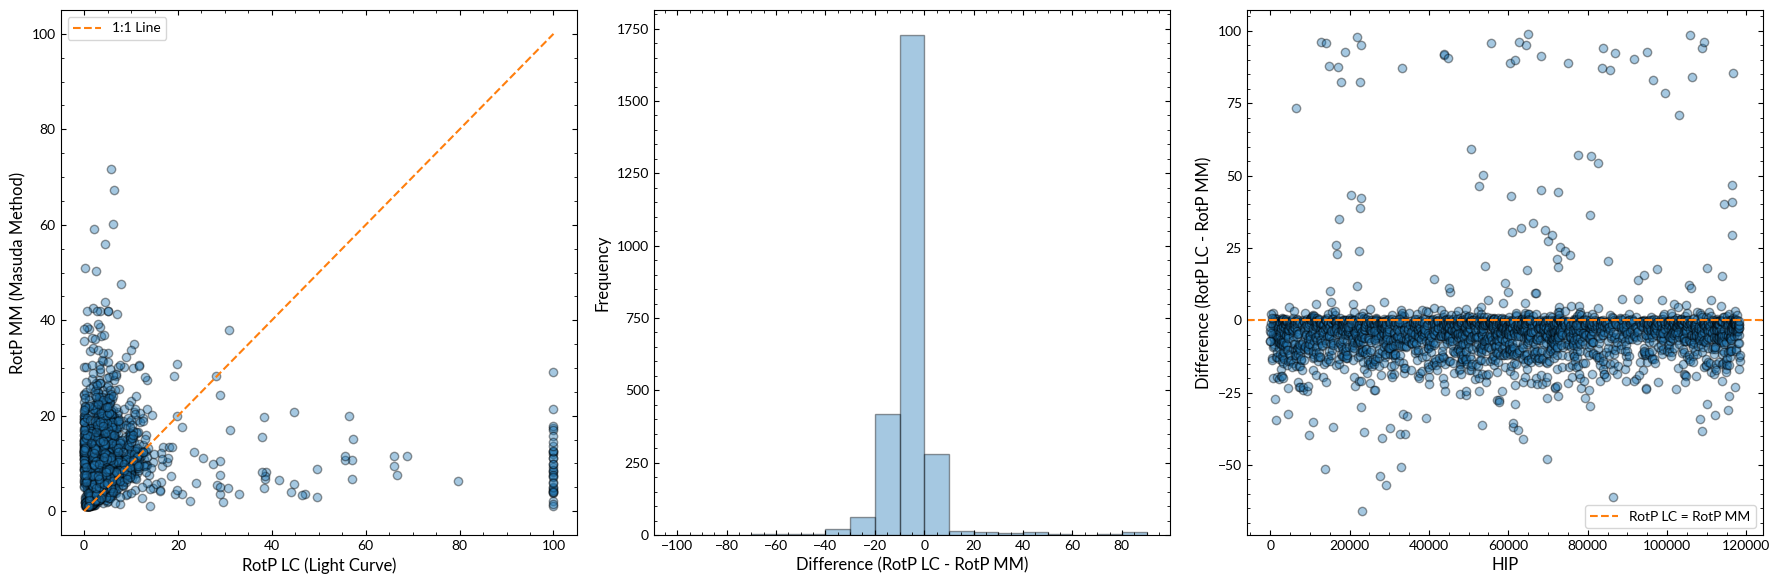

In [68]:
# Aqui vamos ver o quanto difere os resultados via curva de luz e do Masuda (2022)
teste = pd.merge(df, masuda, on="HIP").dropna(subset=["RotP"])

# Calcular a diferença entre os valores de RotP e p_max_like
teste["difference"] = teste["RotP"] - teste["p_max_like"]

min_difference = int(teste["difference"].min()) - 34
max_difference = int(teste["difference"].max()) + 2
intervalos = range(min_difference, max_difference, 10)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Primeiro subplot: RotP vs p_max_like
axs[0].scatter(teste["RotP"], teste["p_max_like"], c='C0', edgecolor='k',  alpha=0.4)
axs[0].plot([teste["RotP"].min(), teste["RotP"].max()], [teste["RotP"].min(), teste["RotP"].max()], 
            color='C1', linestyle='--', label='1:1 Line')
axs[0].set_xlabel('RotP LC (Light Curve)')
axs[0].set_ylabel('RotP MM (Masuda Method)')
axs[0].legend()

# Segundo subplot: Histograma das diferenças
axs[1].hist(teste["difference"], bins=intervalos, color='C0', edgecolor='k',  alpha=0.4)
axs[1].set_xticks(intervalos[::2])
axs[1].set_xlabel('Difference (RotP LC - RotP MM)')
axs[1].set_ylabel('Frequency')

# Terceiro subplot: Gráfico de dispersão das diferenças
axs[2].scatter(teste["HIP"], teste["difference"], c='C0', edgecolor='k',  alpha=0.4)
axs[2].axhline(y=0, color="C1", ls="--", label="RotP LC = RotP MM")
axs[2].set_xlabel('HIP')
axs[2].set_ylabel('Difference (RotP LC - RotP MM)')
axs[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [21]:
dados = df.dropna(subset={"RotP", "radius_val"}, axis = 0).copy()
dados["inclinacao"] = dados.apply(calcular_inclinacao, axis=1, rotation_col="RotP")

In [23]:
masuda["inclination"] = masuda.apply(calcular_inclinacao, axis=1, rotation_col="p_max_like")

# Refazendo os passos agora para inclinação

In [5]:
x, y, i = dados["X"].values, dados["Y"].values, dados["inclinacao"].values

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

# Intervalo para construir o espaço de análise
interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

# Número de intervalos ao longo de x e y
Nx = len(ttx) - 1
Ny = len(tty) - 1

# Percentual de corte para a média truncada
trimpct = 20

# Processamento principal dos dados
meanoriginal, boot_mean, boot_se, ci1, ci2, largura, shape, countfXY, sigma_distance = sts.process_data(ttx, tty, x, y, i, B, trimpct)

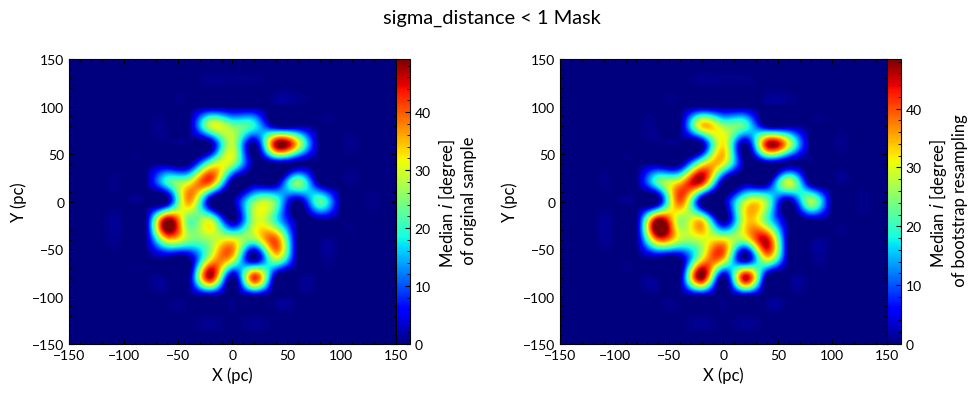

In [6]:
# Considerando que sigma_distance < 1 seja nosso critério
mask = sigma_distance < 1

# Plotagem dos resultados usando a máscara para filtrar dados
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots = [(meanoriginal * mask, 'Median $i$ [degree] \n of original sample'),
         (boot_mean * mask, 'Median $i$ [degree] \n of bootstrap resampling')]

for ax, (data, label) in zip(axs.flat, plots):
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet', interpolation=method, extent=(-ul, ul, -ul, ul))
    plt.suptitle("sigma_distance < 1 Mask")
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    cbar.set_label(label)
    
fig.tight_layout()
plt.show()

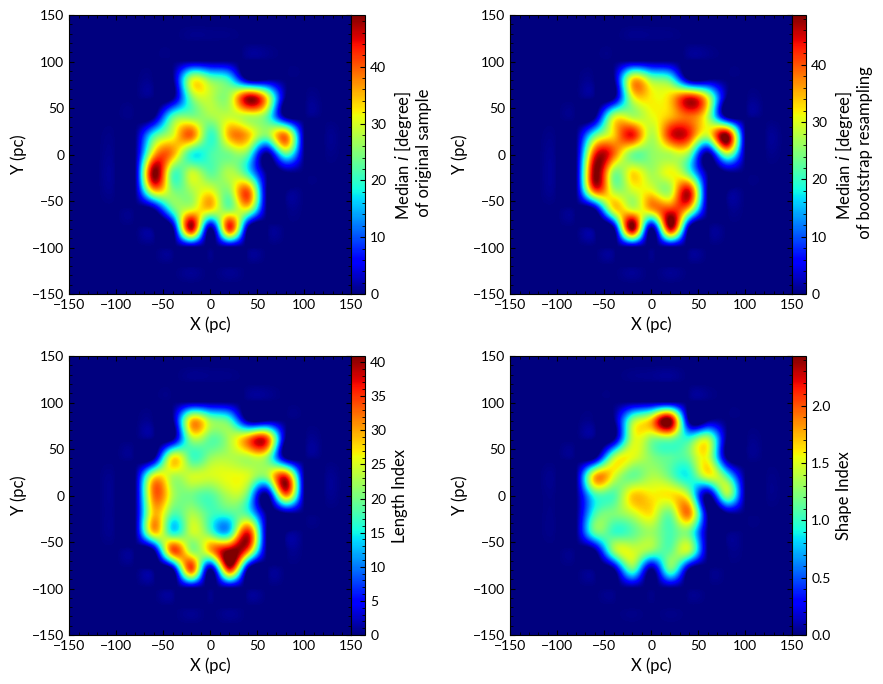

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
plots = [(meanoriginal, 'Median $i$ [degree] \n of original sample'),
         (boot_mean, 'Median $i$ [degree] \n of bootstrap resampling'),
         (largura, 'Length Index'),
         (shape, 'Shape Index')]

for ax, (data, label) in zip(axs.flat, plots):
    niter = 1
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet',interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    
    if ax == axs[0, 0]:
        cbar.set_label(label)
        cbar.formatter = plt.FuncFormatter(lambda x, _: f'{int(x):d}')
        cbar.update_ticks()
    else:
        cbar.set_label(label)
        
fig.tight_layout()
plt.show()

# Refazendo os passos agora para periodo de rotação e inclinação USANDO MASUDA (2022)

## Inclinação

In [30]:
x, y, i = masuda["X"].values, masuda["Y"].values, masuda["inclination"].values

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

# Intervalo para construir o espaço de análise
interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

# Número de intervalos ao longo de x e y
Nx = len(ttx) - 1
Ny = len(tty) - 1

# Percentual de corte para a média truncada
trimpct = 20

# Processamento principal dos dados
meanoriginal, boot_mean, boot_se, ci1, ci2, largura, shape, countfXY, sigma_distance = sts.process_data(ttx, tty, x, y, i, B, trimpct)

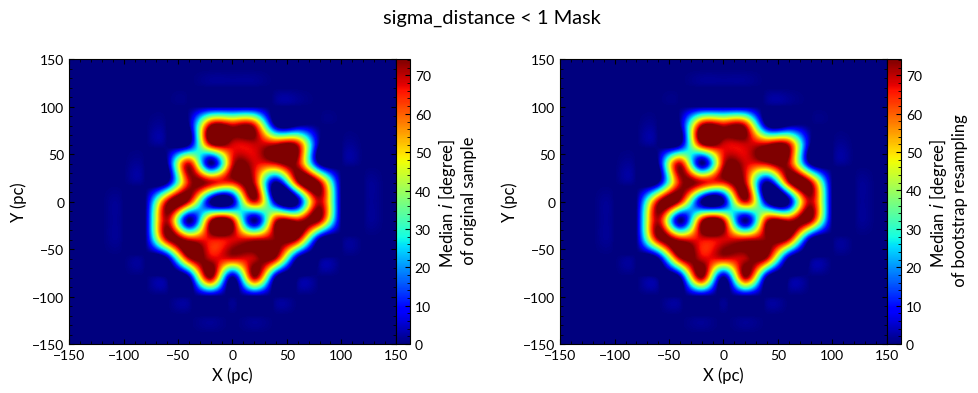

In [31]:
# Considerando que sigma_distance < 1 seja nosso critério
mask = sigma_distance < 1

# Plotagem dos resultados usando a máscara para filtrar dados
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots = [(meanoriginal * mask, 'Median $i$ [degree] \n of original sample'),
         (boot_mean * mask, 'Median $i$ [degree] \n of bootstrap resampling')]

for ax, (data, label) in zip(axs.flat, plots):
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet', interpolation=method, extent=(-ul, ul, -ul, ul))
    plt.suptitle("sigma_distance < 1 Mask")
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    cbar.set_label(label)
    
fig.tight_layout()
plt.show()

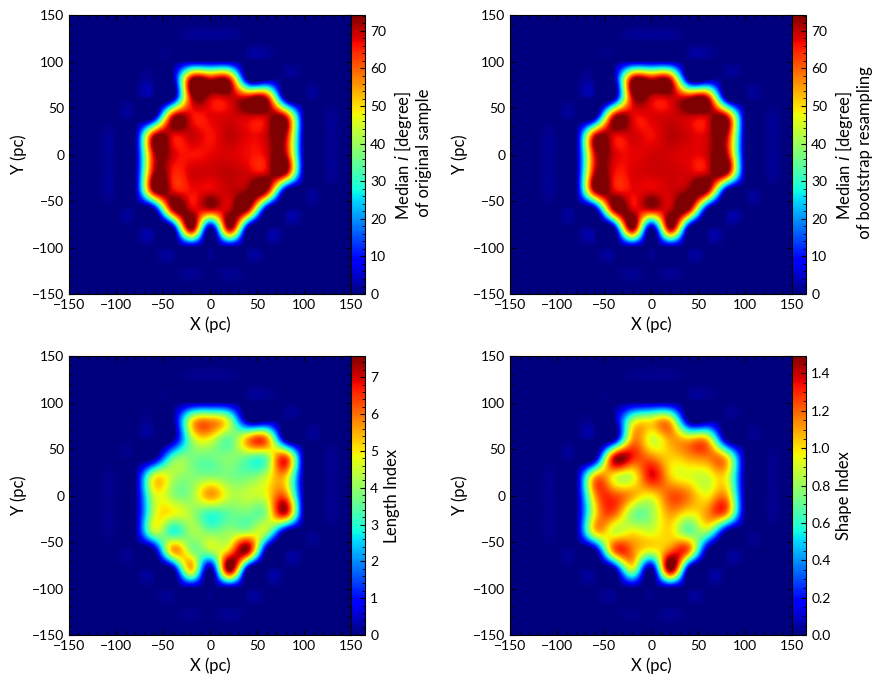

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
plots = [(meanoriginal, 'Median $i$ [degree] \n of original sample'),
         (boot_mean, 'Median $i$ [degree] \n of bootstrap resampling'),
         (largura, 'Length Index'),
         (shape, 'Shape Index')]

for ax, (data, label) in zip(axs.flat, plots):
    niter = 1
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet',interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    
    if ax == axs[0, 0]:
        cbar.set_label(label)
        cbar.formatter = plt.FuncFormatter(lambda x, _: f'{int(x):d}')
        cbar.update_ticks()
    else:
        cbar.set_label(label)
        
fig.tight_layout()
plt.show()

## Período de rotação

In [33]:
x, y, i = masuda["X"].values, masuda["Y"].values, masuda["p_max_like"].values

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

# Intervalo para construir o espaço de análise
interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

# Número de intervalos ao longo de x e y
Nx = len(ttx) - 1
Ny = len(tty) - 1

# Percentual de corte para a média truncada
trimpct = 20

# Processamento principal dos dados
meanoriginal, boot_mean, boot_se, ci1, ci2, largura, shape, countfXY, sigma_distance = sts.process_data(ttx, tty, x, y, i, B, trimpct)

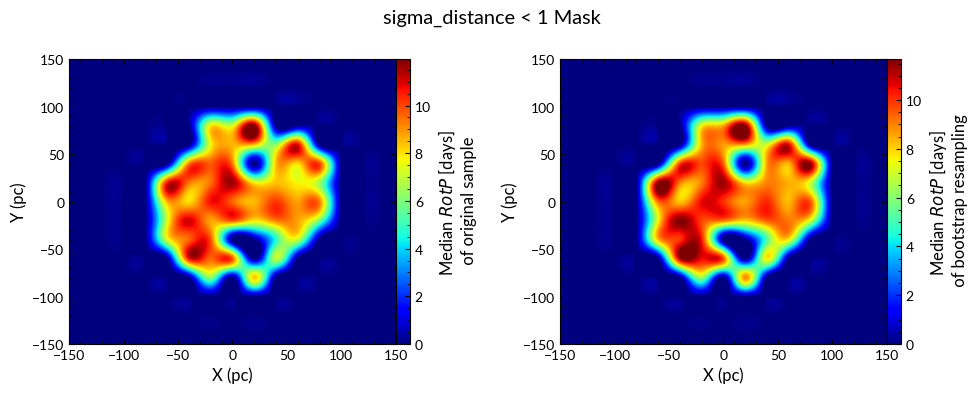

In [34]:
# Considerando que sigma_distance < 1 seja nosso critério
mask = sigma_distance < 1

# Plotagem dos resultados usando a máscara para filtrar dados
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots = [(meanoriginal * mask, 'Median $RotP$ [days] \n of original sample'),
         (boot_mean * mask, 'Median $RotP$ [days] \n of bootstrap resampling')]

for ax, (data, label) in zip(axs.flat, plots):
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet', interpolation=method, extent=(-ul, ul, -ul, ul))
    plt.suptitle("sigma_distance < 1 Mask")
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    cbar.set_label(label)
    
fig.tight_layout()
plt.show()

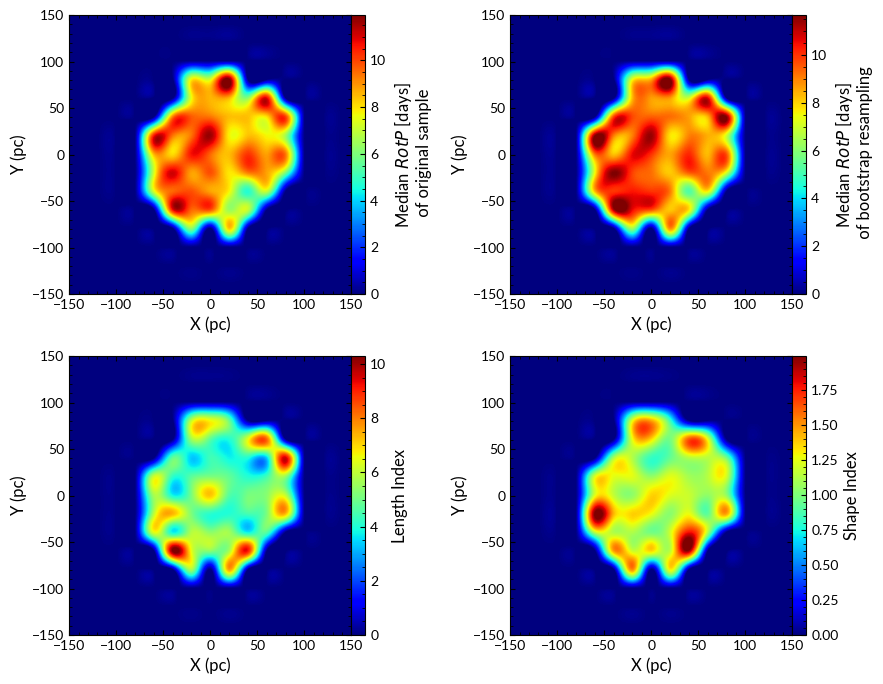

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
plots = [(meanoriginal, 'Median $RotP$ [days] \n of original sample'),
         (boot_mean, 'Median $RotP$ [days] \n of bootstrap resampling'),
         (largura, 'Length Index'),
         (shape, 'Shape Index')]

for ax, (data, label) in zip(axs.flat, plots):
    niter = 1
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet',interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    
    if ax == axs[0, 0]:
        cbar.set_label(label)
        cbar.formatter = plt.FuncFormatter(lambda x, _: f'{int(x):d}')
        cbar.update_ticks()
    else:
        cbar.set_label(label)
        
fig.tight_layout()
plt.show()

# Verificando no GAIA DR3 se temos dados de período de rotação 

In [70]:
gaia_dr3 = "https://cdsarc.cds.unistra.fr/viz-bin/nph-Cat/txt?I/358/vrm.dat"
colunas = ["solution_id", "num_segments", "num_outliers", "best_rotation_period", 
          "best_rotation_period_error", "g_unspotted", "g_unspotted_error", "bp_unspotted", 
          "bp_unspotted_error", "rp_unspotted", "rp_unspotted_error", "max_activity_index_g", 
          "max_activity_index_g_error", "ra", "de"]
gaia_dr3_df = pd.read_csv(gaia_dr3, names=colunas, sep="|", skiprows=5)

In [71]:
# Aqui eu só esotu pegando o Source ID 
source_id = pd.read_csv("../data/Fstars_with_radius_DR2.csv")

# Aqui estamos revisitando os dados de período que computamos via LC
periodos_LC = pd.read_csv("../data/Fstars_with_periods.csv")

In [72]:
# Vamos ver quais são so dados que temos de fato valores de período de rotação
merged_df = pd.merge(source_id, gaia_dr3_df, left_on='source_id', right_on='solution_id', how='inner')
merged_df[["target_id", "best_rotation_period"]]

,target_id,best_rotation_period
0,HD 8523,7.0
1,HD 15394,12.0


In [73]:
comparar = pd.merge(merged_df, masuda, left_on='target_id', right_on='Name', how='inner')[["Name", "best_rotation_period", "p_max_like"]]
comparar

,Name,best_rotation_period,p_max_like
0,HD 8523,7.0,6.350425
1,HD 15394,12.0,2.731722


In [76]:
comparar2 = pd.merge(comparar, periodos_LC, left_on='Name', right_on='Name', how='inner')
comparar2.columns = ["Name", "Original RotP", "Masuda Method", "Light Curve"]
comparar2

,Name,Original RotP,Masuda Method,Light Curve
0,HD 8523,7.0,6.350425,79.733027
1,HD 15394,12.0,2.731722,2.472083


In [8]:
# Salvando para mandar para o Kento Masuda
df = pd.read_csv("../data/Fstars_with_periods_masuda.csv")
sample = df[["Name", "vsini", "radius_val", "radius_percentile_lower", "radius_percentile_upper"]]
sample.to_csv("../data/Fstars_sample.csv", index=False)